In [1]:
import pandas as pd
import numpy as np


import matplotlib as plt

import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_cars.csv")

In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 243784 entries, 0 to 243783
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     243784 non-null  str    
 1   model                     243784 non-null  str    
 2   color                     243700 non-null  str    
 3   registration_date         243784 non-null  str    
 4   year                      243784 non-null  int64  
 5   price_in_euro             243784 non-null  int64  
 6   power_kw                  243657 non-null  float64
 7   power_ps                  243657 non-null  float64
 8   transmission_type         243784 non-null  str    
 9   fuel_type                 243784 non-null  str    
 10  fuel_consumption_l_100km  217234 non-null  str    
 11  fuel_consumption_g_km     243784 non-null  str    
 12  mileage_in_km             243731 non-null  float64
dtypes: float64(3), int64(2), str(8)
memory usage: 24.2 MB
N

In [4]:
brand_counts = df["brand"].value_counts()

print(brand_counts)

brand
volkswagen       32901
mercedes-benz    26898
audi             20797
opel             19748
bmw              19665
ford             18215
skoda            13469
seat             11460
renault           8209
toyota            7543
hyundai           6793
peugeot           5625
kia               5507
fiat              4548
mini              4259
mazda             4168
volvo             4112
porsche           3903
citroen           3688
nissan            3629
dacia             3089
land-rover        3018
smart             1620
jeep              1594
alfa-romeo        1384
jaguar            1361
mitsubishi         923
honda              771
maserati           678
dodge              655
ferrari            587
bentley            538
lamborghini        357
ssangyong          338
aston-martin       276
saab               231
daihatsu           203
chevrolet          189
lada               189
cadillac           156
isuzu              131
infiniti           112
lancia             105
daewo

In [5]:
brand_counts.head(20)

brand
volkswagen       32901
mercedes-benz    26898
audi             20797
opel             19748
bmw              19665
ford             18215
skoda            13469
seat             11460
renault           8209
toyota            7543
hyundai           6793
peugeot           5625
kia               5507
fiat              4548
mini              4259
mazda             4168
volvo             4112
porsche           3903
citroen           3688
nissan            3629
Name: count, dtype: int64

In [6]:
brand_percent = (
    df["brand"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

brand_percent

brand
volkswagen       13.50
mercedes-benz    11.03
audi              8.53
opel              8.10
bmw               8.07
ford              7.47
skoda             5.52
seat              4.70
renault           3.37
toyota            3.09
hyundai           2.79
peugeot           2.31
kia               2.26
fiat              1.87
mini              1.75
mazda             1.71
volvo             1.69
porsche           1.60
citroen           1.51
nissan            1.49
dacia             1.27
land-rover        1.24
smart             0.66
jeep              0.65
alfa-romeo        0.57
jaguar            0.56
mitsubishi        0.38
honda             0.32
maserati          0.28
dodge             0.27
ferrari           0.24
bentley           0.22
lamborghini       0.15
ssangyong         0.14
aston-martin      0.11
saab              0.09
daihatsu          0.08
chevrolet         0.08
lada              0.08
cadillac          0.06
isuzu             0.05
infiniti          0.05
lancia            0.04
daewo

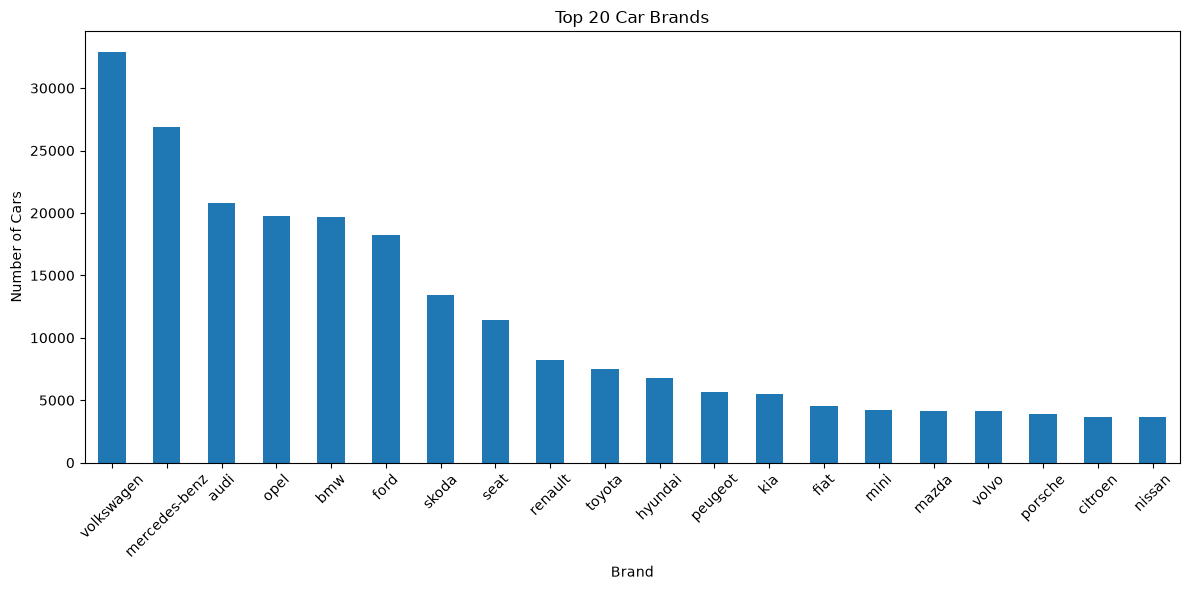

In [7]:
import matplotlib.pyplot as plt

brand_counts.head(20).plot(kind="bar", figsize=(12,6))

plt.title("Top 20 Car Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. Fuel Type

In [8]:
fuel_counts = df["fuel_type"].value_counts()

print(fuel_counts)

fuel_type
Petrol           139086
Diesel            84694
Hybrid            11657
Electric           5871
LPG                1143
CNG                 506
Diesel Hybrid       465
Other               175
Unknown              96
Hydrogen             81
Ethanol              10
Name: count, dtype: int64


In [9]:
fuel_percent = (
    df["fuel_type"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

fuel_percent

fuel_type
Petrol           57.05
Diesel           34.74
Hybrid            4.78
Electric          2.41
LPG               0.47
CNG               0.21
Diesel Hybrid     0.19
Other             0.07
Unknown           0.04
Hydrogen          0.03
Ethanol           0.00
Name: proportion, dtype: float64

In [11]:
main_fuels = ["Petrol", "Diesel", "Hybrid", "Electric"]

df["fuel_type"] = df["fuel_type"].apply(
    lambda x: x if x in main_fuels else "Other"
)

In [12]:
df["fuel_type"].value_counts()

fuel_type
Petrol      139086
Diesel       84694
Hybrid       11657
Electric      5871
Other         2476
Name: count, dtype: int64

Быстрая проверка качества target

In [15]:
df["price_in_euro"].head(20)

0      1300
1     24900
2      5900
3      4900
4     17950
5      7900
6      3500
7      5500
8      8990
9      6976
10     5499
11     8499
12     2290
13    15800
14     7950
15     1300
16     6900
17    16900
18     9980
19    11990
Name: price_in_euro, dtype: int64

In [17]:
bad_price = df[~df["price_in_euro"].astype(str).str.fullmatch(r"\d+")]

print(len(bad_price))
bad_price["price_in_euro"].value_counts().head(20)

0


Series([], Name: count, dtype: int64)

In [18]:
good_price = df[df["price_in_euro"].astype(str).str.fullmatch(r"\d+")]

print("Good rows:", len(good_price))
print("Bad rows:", len(df) - len(good_price))

Good rows: 243784
Bad rows: 0


In [19]:
clean_price = pd.to_numeric(good_price["price_in_euro"])

In [20]:
clean_price.describe()

count    2.437840e+05
mean     2.605952e+04
std      3.734218e+04
min      1.200000e+02
25%      1.190000e+04
50%      1.960000e+04
75%      2.990000e+04
max      5.890500e+06
Name: price_in_euro, dtype: float64

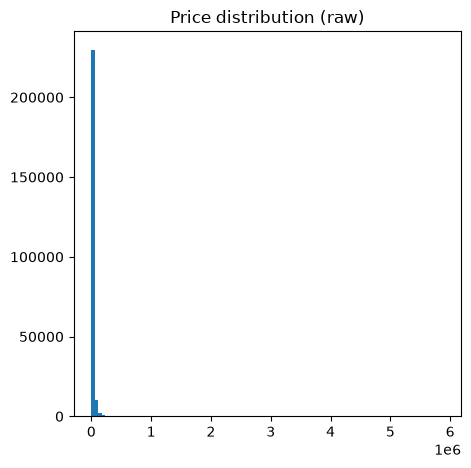

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.hist(df["price_in_euro"], bins=100)
plt.title("Price distribution (raw)")
plt.show()

In [22]:
clean_price.max()

np.int64(5890500)

In [24]:
Q1 = df["price_in_euro"].quantile(0.25)
Q3 = df["price_in_euro"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[
    (df["price_in_euro"] >= lower) &
    (df["price_in_euro"] <= upper)
]

In [25]:
df_clean["price_in_euro"].describe()

count    228626.000000
mean      20312.615709
std       12021.472264
min         120.000000
25%       11200.000000
50%       18590.000000
75%       27449.000000
max       56900.000000
Name: price_in_euro, dtype: float64

In [38]:
expensive = df[df["price_in_euro"] > 1000000].sort_values(
    "price_in_euro", ascending=False
)

expensive[[
    "brand",
    "model",
    "year",
    "price_in_euro",
    "mileage_in_km",
    "registration_date"
]]

,brand,model,year,price_in_euro,mileage_in_km,registration_date
90663,lamborghini,Lamborghini,2018,5890500,65.0,08/2018
90804,lamborghini,Lamborghini,2021,3250000,177.0,11/2021
103405,mercedes-benz,Mercedes-Benz SLR,2007,2490000,15793.0,01/2007
1456,aston-martin,Aston Martin,2011,2289000,8900.0,08/2011
160891,porsche,Porsche 918,2014,1990000,5125.0,06/2014
160070,porsche,Porsche Carrera GT,2006,1580000,13460.0,04/2006
160047,porsche,Porsche Carrera GT,2005,1549000,26800.0,04/2005
161227,porsche,Porsche 991,2015,1350000,27000.0,01/2015
50998,ferrari,Ferrari F12,2017,1290000,10800.0,04/2017
160709,porsche,Porsche 918,2014,1290000,31490.0,07/2014


In [39]:
df = df[df["price_in_euro"] <= 1_000_000].copy()

In [40]:
df["price_in_euro"].max()

np.int64(1000000)

In [41]:
print(df["price_in_euro"].max())

1000000


In [42]:
print(df.shape)

(243769, 14)


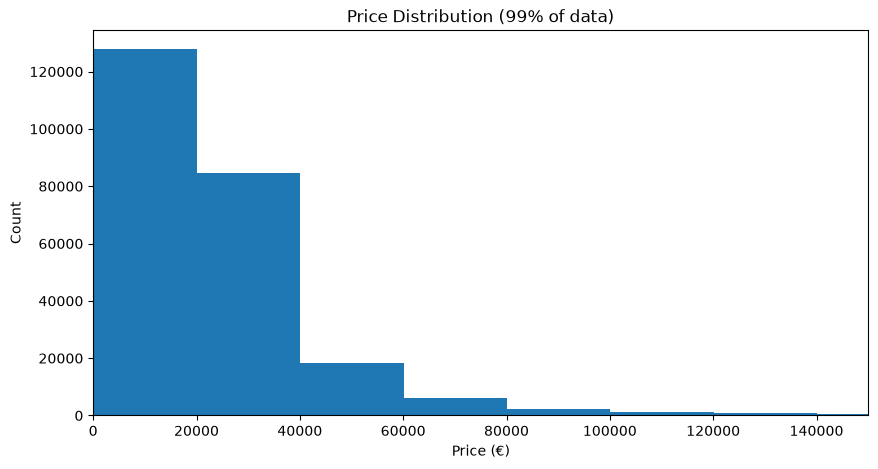

In [43]:
limit = df["price_in_euro"].quantile(0.99)

plt.figure(figsize=(10,5))
plt.hist(df["price_in_euro"], bins=50)
plt.xlim(0, limit)

plt.title("Price Distribution (99% of data)")
plt.xlabel("Price (€)")
plt.ylabel("Count")

plt.show()

In [47]:
df[df["price_in_euro"] > 100000].shape

(4762, 14)

In [50]:
df['registration_date'].head(10)

0   1995-10-01
1   1995-02-01
2   1995-02-01
3   1995-07-01
4   1996-11-01
5   1996-04-01
6   1996-12-01
7   1996-07-01
8   1996-07-01
9   1996-01-01
Name: registration_date, dtype: datetime64[us]

In [48]:
df['registration_date'] = pd.to_datetime(df['registration_date'], errors='coerce')
df['reg_year'] = df['registration_date'].dt.year

C:\Users\User\AppData\Local\Temp\ipykernel_3456\2773465408.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['registration_date'] = pd.to_datetime(df['registration_date'], errors='coerce')


In [49]:
df['registration_date'].head(10)

0   1995-10-01
1   1995-02-01
2   1995-02-01
3   1995-07-01
4   1996-11-01
5   1996-04-01
6   1996-12-01
7   1996-07-01
8   1996-07-01
9   1996-01-01
Name: registration_date, dtype: datetime64[us]

In [51]:
df['registration_date'] = pd.to_datetime(
    df['registration_date'],
    format='%Y-%m-%d',
    errors='coerce'
)

In [52]:
df['reg_year'] = df['registration_date'].dt.year

In [53]:
df['registration_date'].isna().sum()

np.int64(0)

In [59]:
df['reg_year'].min(), df['reg_year'].max()

(np.int32(1995), np.int32(2023))

In [60]:
(df['reg_year'] - df['year']).describe()

count    243769.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
dtype: float64

In [61]:
df['car_age'] = 2026 - df['year']

In [62]:
df = df.drop(columns=['year', 'reg_year', 'registration_date'])

In [64]:
df = df.drop(columns=['reg_age'])

In [65]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
Index: 243769 entries, 0 to 243783
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     243769 non-null  str    
 1   model                     243769 non-null  str    
 2   color                     243685 non-null  str    
 3   price_in_euro             243769 non-null  int64  
 4   power_kw                  243642 non-null  float64
 5   power_ps                  243642 non-null  float64
 6   transmission_type         243769 non-null  str    
 7   fuel_type                 243769 non-null  str    
 8   fuel_consumption_l_100km  217224 non-null  str    
 9   fuel_consumption_g_km     243769 non-null  str    
 10  mileage_in_km             243716 non-null  float64
 11  price_log                 243769 non-null  float64
 12  car_age                   243769 non-null  int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 26.0 MB
None
b

In [57]:
import numpy as np

df["price_log"] = np.log1p(df["price_in_euro"])

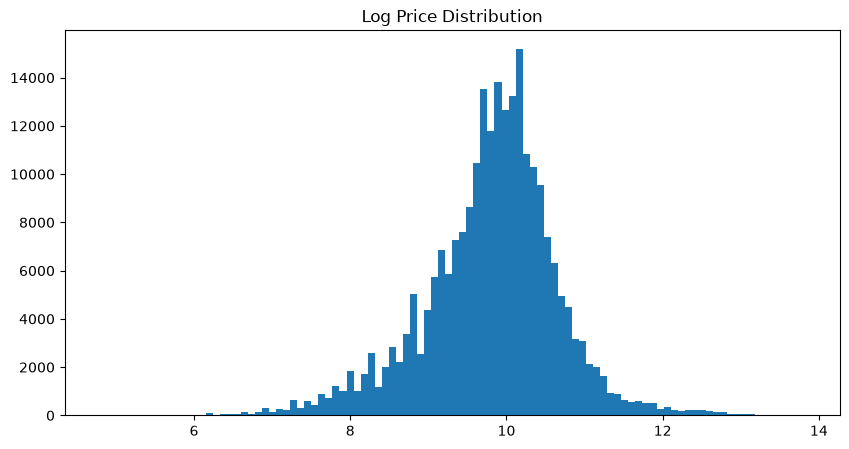

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["price_log"], bins=100)
plt.title("Log Price Distribution")
plt.show()

In [66]:
df['fuel_consumption_g_km'].describe()

count       243769
unique        1434
top       - (g/km)
freq         35511
Name: fuel_consumption_g_km, dtype: object

In [67]:
df['fuel_consumption_g_km'].head(10)

0    260 g/km
1    - (g/km)
2    - (g/km)
3    225 g/km
4    - (g/km)
5    225 g/km
6    210 g/km
7    320 g/km
8    265 g/km
9    220 g/km
Name: fuel_consumption_g_km, dtype: str

In [68]:
df.rename(
    columns={'fuel_consumption_g_km': 'co2_emissions_g_km'},
    inplace=True
)

In [69]:
df['co2_emissions_g_km'] = (
    df['co2_emissions_g_km']
      .str.extract(r'(\d+)')
      .astype(float)
)

In [70]:
df['co2_emissions_g_km'].head()

0    260.0
1      NaN
2      NaN
3    225.0
4      NaN
Name: co2_emissions_g_km, dtype: float64

In [71]:
df['co2_emissions_g_km'].isna().sum()

np.int64(36399)

In [72]:
df['has_fuel_consumption'] = df['fuel_consumption_l_100km'].notna().astype(int)
df['has_co2'] = df['co2_emissions_g_km'].notna().astype(int)

In [73]:
df['is_electric'] = (df['fuel_type'] == 'Electric').astype(int)

In [74]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
Index: 243769 entries, 0 to 243783
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     243769 non-null  str    
 1   model                     243769 non-null  str    
 2   color                     243685 non-null  str    
 3   price_in_euro             243769 non-null  int64  
 4   power_kw                  243642 non-null  float64
 5   power_ps                  243642 non-null  float64
 6   transmission_type         243769 non-null  str    
 7   fuel_type                 243769 non-null  str    
 8   fuel_consumption_l_100km  217224 non-null  str    
 9   co2_emissions_g_km        207370 non-null  float64
 10  mileage_in_km             243716 non-null  float64
 11  price_log                 243769 non-null  float64
 12  car_age                   243769 non-null  int64  
 13  has_fuel_consumption      243769 non-null  int64  
 14  has_

In [75]:
df.drop(columns=['power_ps'], inplace=True)
df['power_kw'] = df['power_kw'].fillna(df['power_kw'].median())

In [76]:
df['fuel_consumption_l_100km'] = df['fuel_consumption_l_100km'].str.extract(r'(\d+\.?\d*)').astype(float)

df.loc[df['fuel_type'] == 'Electric', 'fuel_consumption_l_100km'] = 0

df['fuel_consumption_l_100km'] = df['fuel_consumption_l_100km'].fillna(
    df.groupby('fuel_type')['fuel_consumption_l_100km'].transform('median')
)

In [77]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
Index: 243769 entries, 0 to 243783
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     243769 non-null  str    
 1   model                     243769 non-null  str    
 2   color                     243685 non-null  str    
 3   price_in_euro             243769 non-null  int64  
 4   power_kw                  243769 non-null  float64
 5   transmission_type         243769 non-null  str    
 6   fuel_type                 243769 non-null  str    
 7   fuel_consumption_l_100km  243769 non-null  float64
 8   co2_emissions_g_km        207370 non-null  float64
 9   mileage_in_km             243716 non-null  float64
 10  price_log                 243769 non-null  float64
 11  car_age                   243769 non-null  int64  
 12  has_fuel_consumption      243769 non-null  int64  
 13  has_co2                   243769 non-null  int64  
 14  is_e

In [78]:
df.to_csv("cleaned_cars_2.csv", index=False)

In [79]:
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
Index: 243769 entries, 0 to 243783
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     243769 non-null  str    
 1   model                     243769 non-null  str    
 2   color                     243685 non-null  str    
 3   price_in_euro             243769 non-null  int64  
 4   power_kw                  243769 non-null  float64
 5   transmission_type         243769 non-null  str    
 6   fuel_type                 243769 non-null  str    
 7   fuel_consumption_l_100km  243769 non-null  float64
 8   co2_emissions_g_km        207370 non-null  float64
 9   mileage_in_km             243716 non-null  float64
 10  price_log                 243769 non-null  float64
 11  car_age                   243769 non-null  int64  
 12  has_fuel_consumption      243769 non-null  int64  
 13  has_co2                   243769 non-null  int64  
 14  is_e